# PFA - Reconnaissance des Emotions Faciales
## Etape 2 : Chargement et preparation des donnees FER2013

**Equipe :** Ayman TEMSAMANI, Nouhaila AIT ABDELAH, Rabab ZITI  
**Encadrant :** Pr. Redouane DAHBI  
**Date :** Semaine S1-S2 (Phase 1 du planning)

**Contexte :** Le dataset FER2013 a ete telecharge depuis Kaggle sous forme de dossiers train/test. Chaque dossier contient 7 sous-dossiers correspondant aux 7 emotions : angry, disgust, fear, happy, neutral, sad, surprise. L'objectif de cette etape est de charger ces images en memoire sans ecrire de boucle manuelle, en utilisant la classe ImageDataGenerator de Keras qui automatise la totalite du pipeline de chargement.

In [1]:
# ============================================================
#  SECTION 1 : Import des bibliotheques necessaires
# ============================================================

# ImageDataGenerator est une classe du module keras.preprocessing.image.
# Elle permet de charger des images directement depuis des dossiers,
# de les redimensionner, de les convertir en niveaux de gris,
# et d'assigner automatiquement les labels en fonction du nom du sous-dossier.
# J'utilise cette classe plutot qu'une boucle manuelle avec OpenCV
# car elle est optimisee pour l'entrainement de modeles Keras :
# elle charge les images par batchs, ce qui evite de saturer la RAM.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# matplotlib.pyplot est une bibliotheque d'affichage de graphiques.
# Je l'importe pour pouvoir verifier visuellement que les images
# ont ete correctement chargees et normalisees.
import matplotlib.pyplot as plt

# numpy est la bibliotheque fondamentale de calcul scientifique en Python.
# Je l'utilise ici pour la fonction argmax() qui permet d'extraire
# l'indice de la classe a partir d'un vecteur one-hot encoding.
import numpy as np

In [ ]:
import sys
print(sys.executable)

c:\Users\ayman\anaconda3\python.exe


---
### Justification theorique de la normalisation (rescale = 1./255)

Les images brutes sont codees sur 8 bits par pixel, ce qui donne des valeurs entieres comprises entre 0 (pixel noir) et 255 (pixel blanc). L'injection de ces valeurs brutes dans un reseau de neurones convolutif pose trois problemes majeurs :

**Probleme 1 : Instabilite numerique.** Les poids du reseau sont initialises avec de petites valeurs (ex: initialisation Glorot). Lors de la passe avant, les activations deviennent rapidement tres grandes (ex: une entree de 255 multipliee par une matrice de poids). Lors de la retropropagation, les gradients explosent, ce qui empeche la convergence.

**Probleme 2 : Convergence lente.** L'optimiseur Adam utilise les moments du gradient pour ajuster le taux d'apprentissage. Avec des entrees non normalisees, les gradients ont des echelles tres differentes selon les couches, ce qui ralentit considerablement l'apprentissage et necessite plus d'epoques.

**Probleme 3 : Absence d'echelle commune.** Chaque image possede sa propre distribution de pixels. Le reseau doit alors apprendre a la fois la normalisation et la tache de classification, ce qui complexifie inutilement l'optimisation.

**Solution adoptee :** La division de chaque pixel par 255 (rescale=1./255) ramene toutes les valeurs dans l'intervalle continu [0.0, 1.0]. Cette transformation presente les proprietes suivantes :
- Simplicite d'implementation (une seule operation)
- Reversibilite (multiplication par 255 pour retrouver l'image originale)
- Standard dans la litterature sur FER2013 (Goodfellow et al., 2013)
- Aucun parametre a apprendre (contrairement a la Batch Normalization)

**Contrainte critique :** La meme normalisation doit etre appliquee aux ensembles d'entrainement ET de test. Si le modele est entraine sur des valeurs dans [0,1] et teste sur des valeurs dans [0,255], il recevra des entrees 255 fois plus grandes que ce qu'il a appris a traiter, ce qui produira des predictions aleatoires.
---

In [2]:
# ============================================================
#  SECTION 2 : Creation des generateurs avec normalisation
# ============================================================

# Je cree un premier objet ImageDataGenerator pour l'entrainement.
# Le parametre rescale=1./255 indique que chaque valeur de pixel
# doit etre multipliee par 1/255, ce qui equivaut a une division par 255.
# Aucune autre transformation n'est appliquee pour le moment.
# La data augmentation (rotations, zoom, etc.) sera ajoutee ulterieurement
# dans la Phase 2 du planning, une fois le pipeline de base valide.
train_datagen = ImageDataGenerator(rescale=1./255)

# Je cree un second objet ImageDataGenerator pour le test.
# Il recoit exactement le meme parametre de normalisation.
# Ceci garantit que les images de test subissent la meme transformation
# que les images d'entrainement, condition necessaire pour que
# les predictions du modele soient coherentes.
# Je n'applique JAMAIS de data augmentation sur les donnees de test,
# car cela fausserait l'evaluation des performances reelles du modele.
test_datagen  = ImageDataGenerator(rescale=1./255)

In [3]:
# ============================================================
#  SECTION 3 : Chargement des images d'entrainement
# ============================================================

# J'affiche un message pour indiquer le debut du chargement.
# Cela permet de suivre l'execution dans la console.
print("=" * 60)
print("CHARGEMENT DU JEU D'ENTRAINEMENT")
print("=" * 60)

# La methode flow_from_directory() parcourt le dossier specifie
# et cree un generateur Python qui produit des batchs d'images.
# Chaque sous-dossier du chemin est interprete comme une classe distincte.
# Le nom du sous-dossier devient automatiquement le label.
# Exemple : toutes les images dans "train/happy/" recoivent le label "happy".
train_generator = train_datagen.flow_from_directory(
    
    # Chemin absolu vers le dossier d'entrainement.
    # Ce dossier contient 7 sous-dossiers : angry, disgust, fear,
    # happy, neutral, sad, surprise.
    # J'utilise un chemin absolu pour eviter les erreurs de resolution
    # de chemin relatif selon l'emplacement d'execution du script.
    'C:/Users/ayman/Desktop/PFA/archive/train',
    
    # target_size=(48, 48) : Toutes les images sont redimensionnees
    # a 48 pixels de hauteur et 48 pixels de largeur.
    # Ce choix de dimension est impose par deux contraintes :
    #   1. Le dataset FER2013 original est en 48x48 pixels.
    #   2. L'objectif temps reel du cahier des charges exige
    #      au moins 15 FPS. Une resolution plus elevee (ex: 224x224)
    #      multiplierait le temps d'inference par un facteur significatif.
    target_size=(48, 48),
    
    # color_mode='grayscale' : Les images sont converties en niveaux
    # de gris, ce qui produit un seul canal (au lieu de 3 pour RGB).
    # Cette conversion est justifiee par trois raisons :
    #   1. La couleur n'est pas un facteur discriminant pour les
    #      expressions faciales (une emotion est reconnaissable en N&B).
    #   2. Un seul canal au lieu de trois divise par trois le nombre
    #      de parametres de la premiere couche convolutive, reduisant
    #      le risque de sur-apprentissage.
    #   3. Le dataset FER2013 est nativement en niveaux de gris.
    color_mode='grayscale',
    
    # class_mode='categorical' : Les labels sont encodes en one-hot.
    # Pour 7 classes, chaque label est un vecteur de taille 7 contenant
    # un unique 1 a la position de la classe et des 0 ailleurs.
    # Exemple pour la classe "happy" (position 3) :
    #   [0.  0.  0.  1.  0.  0.  0.]
    # Ce format est requis par la fonction de perte categorical_crossentropy
    # qui sera utilisee pour l'entrainement du modele.
    class_mode='categorical',
    
    # batch_size=32 : Les images sont regroupees par lots de 32.
    # Ce nombre a ete choisi pour les raisons suivantes :
    #   1. 32 est une puissance de 2, ce qui optimise l'allocation
    #      memoire sur GPU (alignement des tenseurs).
    #   2. Un batch de 32 fournit un gradient suffisamment stable
    #      pour la descente de gradient stochastique.
    #   3. Avec des images 48x48 en grayscale, 32 images tiennent
    #      largement dans les 4 Go de VRAM specifies au cahier des charges.
    batch_size=32,
    
    # shuffle=True : Les images sont melangees aleatoirement avant
    # chaque nouvelle epoque. Cette operation est indispensable car :
    #   1. Sans shuffle, le modele verrait toutes les images d'une meme
    #      classe a la suite, ce qui biaiserait l'apprentissage.
    #   2. Le melange garantit que chaque batch contient un echantillon
    #      representatif de la distribution des classes.
    #   3. Cela empeche le modele de memoriser l'ordre des images
    #      plutot que les caracteristiques visuelles des emotions.
    shuffle=True
)

CHARGEMENT DU JEU D'ENTRAINEMENT
Found 28709 images belonging to 7 classes.


In [4]:
# ============================================================
#  SECTION 4 : Chargement des images de test
# ============================================================

# J'affiche un message pour indiquer le debut du chargement du jeu de test.
print("\n" + "=" * 60)
print("CHARGEMENT DU JEU DE TEST")
print("=" * 60)

# Je cree le generateur pour les donnees de test en utilisant
# la meme methode flow_from_directory().
# Les parametres target_size, color_mode, class_mode et batch_size
# sont rigoureusement identiques a ceux du train_generator.
# Cette identite est obligatoire : si les dimensions ou le format
# des entrees different entre l'entrainement et le test, le modele
# ne pourra pas traiter les donnees de test.
test_generator = test_datagen.flow_from_directory(
    
    # Chemin absolu vers le dossier de test.
    # Ce dossier contient la meme arborescence que le dossier train.
    'C:/Users/ayman/Desktop/PFA/archive/test',
    
    # Meme dimension que l'entrainement pour la compatibilite.
    target_size=(48, 48),
    
    # Meme mode couleur pour la compatibilite.
    color_mode='grayscale',
    
    # Meme encodage des labels pour la compatibilite.
    class_mode='categorical',
    
    # Meme taille de batch pour la compatibilite.
    batch_size=32,
    
    # shuffle=False : Contrairement a l'entrainement, les images
    # de test ne sont PAS melangees. Ce choix est motive par :
    #   1. Reproductibilite : l'evaluation doit donner le meme
    #      resultat a chaque execution.
    #   2. Traçabilite : en cas d'erreur sur une prediction, il est
    #      possible d'identifier exactement l'image concernee
    #      car son ordre dans le generateur est deterministe.
    #   3. Comparabilite : differentes versions du modele peuvent
    #      etre comparees equitablement car elles sont evaluees
    #      sur la meme sequence d'images.
    shuffle=False
)


CHARGEMENT DU JEU DE TEST
Found 7178 images belonging to 7 classes.


In [5]:
# ============================================================
#  SECTION 5 : Verification des donnees chargees
# ============================================================

print("\n" + "=" * 60)
print("VERIFICATION DES DONNEES CHARGEES")
print("=" * 60)

# class_indices est un dictionnaire genere automatiquement par
# flow_from_directory(). Il associe chaque nom de sous-dossier
# a un indice numerique. L'ordre est determine par l'ordre
# alphabetique des noms de dossiers.
# Ce mapping est essentiel pour interpreter les predictions
# du modele : la sortie du reseau est un vecteur de probabilites
# sur les indices 0 a 6, et class_indices permet de retrouver
# le nom de l'emotion correspondant a chaque indice.
print("\nMapping des classes (nom -> indice) :")
print(train_generator.class_indices)
# Sortie attendue :
# {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3,
#  'neutral': 4, 'sad': 5, 'surprise': 6}

# L'attribut samples contient le nombre total d'images lues
# par le generateur. Cette valeur est determinee en comptant
# les fichiers image presents dans l'arborescence du dossier.
# Je verifie ce nombre pour m'assurer que toutes les images
# ont bien ete detectees et qu'aucun dossier n'est vide.
print(f"\nNombre total d'images d'entrainement : {train_generator.samples}")
print(f"Nombre total d'images de test          : {test_generator.samples}")
# Pour FER2013 standard, on attend environ :
#   Train : 28,709 images
#   Test  :  7,178 images

# len(generator) renvoie le nombre de batchs par epoque.
# Ce nombre est calcule comme :
#   nb_batchs = ceil(nb_images / batch_size)
# Exemple : 28709 / 32 = 897.15 -> 898 batchs.
# Le dernier batch est plus petit que les autres si le nombre
# total d'images n'est pas un multiple exact de batch_size.
# Le generateur gere automatiquement ce cas.
print(f"\nNombre de batchs par epoque (train) : {len(train_generator)}")
print(f"Nombre de batchs par epoque (test)  : {len(test_generator)}")


VERIFICATION DES DONNEES CHARGEES

Mapping des classes (nom -> indice) :
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Nombre total d'images d'entrainement : 28709
Nombre total d'images de test          : 7178

Nombre de batchs par epoque (train) : 898
Nombre de batchs par epoque (test)  : 225


In [6]:
# ============================================================
#  SECTION 6 : Examen technique d'un batch
# ============================================================

print("\n" + "=" * 60)
print("EXAMEN TECHNIQUE D'UN BATCH")
print("=" * 60)

# next(train_generator) appelle la methode __next__() du generateur.
# Cette methode charge le prochain groupe de 32 images depuis le disque,
# applique les transformations (normalisation uniquement pour l'instant),
# et renvoie un tuple (images, labels).
# Le generateur est infini par defaut : lorsqu'il atteint la fin du dossier,
# il recommence automatiquement au debut (dans un nouvel ordre si shuffle=True).
# Pour un generateur de test avec shuffle=False, il s'arrete apres avoir
# servi toutes les images une fois.
images, labels = next(train_generator)

# images est un tenseur numpy de forme (batch_size, hauteur, largeur, canaux).
# J'affiche sa forme pour verifier que les dimensions correspondent
# exactement a ce que la premiere couche Conv2D du CNN attend.
# La couche Conv2D attend un tenseur 4D : (batch, height, width, channels).
# Si la forme est incorrecte, l'entrainement echouera avec une erreur
# de dimension a la compilation du modele.
print(f"\nForme du batch d'images : {images.shape}")
print("  -> (batch_size=32, hauteur=48, largeur=48, canaux=1)")
# Sortie attendue : (32, 48, 48, 1)

# labels est un tenseur numpy de forme (batch_size, nombre_de_classes).
# Chaque ligne est un vecteur one-hot de dimension 7.
# La somme de chaque ligne vaut toujours 1.0 (une seule classe active).
# Ce format est exactement celui attendu par la fonction de perte
# categorical_crossentropy.
print(f"Forme du batch de labels  : {labels.shape}")
print("  -> (batch_size=32, classes=7) en one-hot encoding")
# Sortie attendue : (32, 7)

# Je verifie que la normalisation a bien ete appliquee en inspectant
# les valeurs minimale et maximale du tenseur d'images.
# Si la normalisation a fonctionne : min proche de 0.0, max proche de 1.0.
# Si la normalisation a echoue (ex: oubli de rescale) : min=0, max=255.
# Cette verification rapide permet de detecter une erreur de configuration
# avant de lancer un entrainement qui serait voue a l'echec.
print(f"\nValeur minimale dans le batch : {images.min():.4f}")
print(f"   -> Attendue proche de 0.0 (pixels noirs)")
print(f"Valeur maximale dans le batch : {images.max():.4f}")
print(f"   -> Attendue proche de 1.0 (pixels blancs)")

# Le type de donnees du tenseur est float32.
# float32 est le type par defaut de TensorFlow/Keras.
# Il offre 32 bits (4 octets) par nombre, ce qui constitue
# un compromis acceptable entre precision numerique et empreinte memoire.
# Pour des images 48x48 en grayscale, le surcout de float64 (8 octets)
# n'est pas justifie par un gain de precision significatif.
print(f"\nType de donnees des images : {images.dtype}")
print("   -> float32 : type standard pour les reseaux de neurones")


EXAMEN TECHNIQUE D'UN BATCH

Forme du batch d'images : (32, 48, 48, 1)
  -> (batch_size=32, hauteur=48, largeur=48, canaux=1)
Forme du batch de labels  : (32, 7)
  -> (batch_size=32, classes=7) en one-hot encoding

Valeur minimale dans le batch : 0.0000
   -> Attendue proche de 0.0 (pixels noirs)
Valeur maximale dans le batch : 1.0000
   -> Attendue proche de 1.0 (pixels blancs)

Type de donnees des images : float32
   -> float32 : type standard pour les reseaux de neurones



AFFICHAGE D'ECHANTILLONS POUR CONTROLE VISUEL


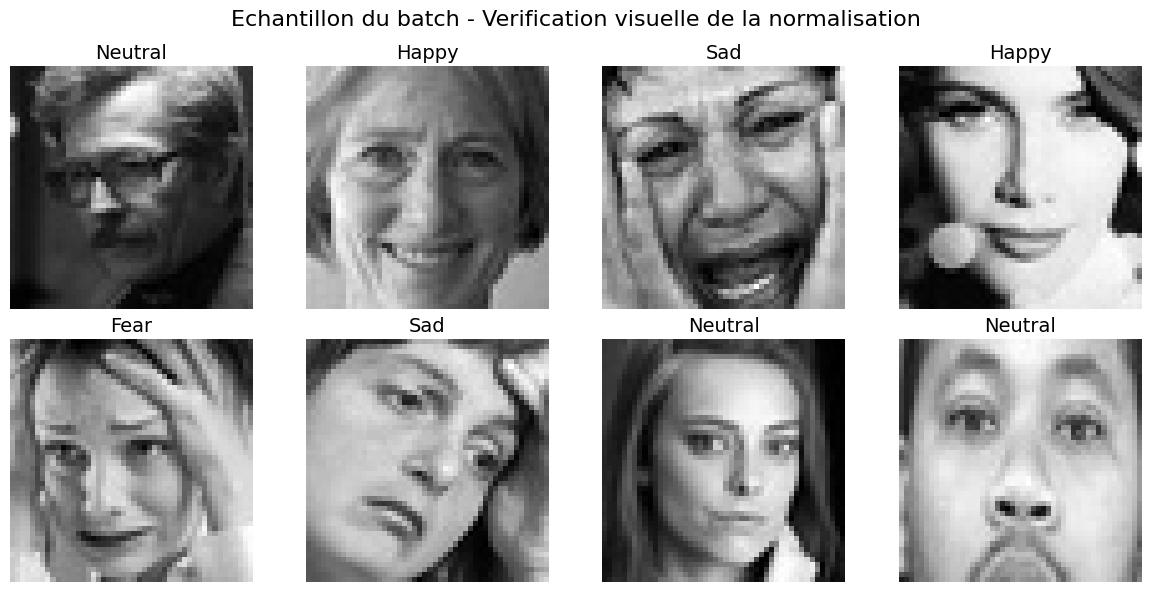

In [7]:
# ============================================================
#  SECTION 7 : Affichage d'echantillons pour controle visuel
# ============================================================

# Je construis un dictionnaire inverse du class_indices.
# class_indices fait : nom -> indice (ex: 'happy' -> 3)
# Ce dictionnaire fait : indice -> nom (ex: 3 -> 'Happy')
# Il servira a afficher le nom lisible de l'emotion
# au lieu de l'indice numerique brut.
# J'utilise des noms avec une majuscule pour l'affichage,
# ce qui est plus presentable que les noms de dossiers en minuscules.
idx_to_emotion = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Neutral',
    5: 'Sad',
    6: 'Surprise'
}

print("\n" + "=" * 60)
print("AFFICHAGE D'ECHANTILLONS POUR CONTROLE VISUEL")
print("=" * 60)

# Je cree une grille de 2 lignes et 4 colonnes pour afficher 8 images.
# Le parametre figsize=(12, 6) definit la taille de la figure en pouces.
# 12 pouces de large pour 6 pouces de haut donne un bon ratio
# pour visualiser 4 images par ligne sans ecrasement.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# axes est une matrice 2D de taille (2, 4).
# axes.flatten() la transforme en liste 1D de 8 elements.
# Cela permet d'iterer avec une simple boucle for sur un indice de 0 a 7
# plutot que de gerer deux boucles imbriquees (i, j).
axes = axes.flatten()

# Je parcours les 8 premieres images du batch.
for i in range(8):
    
    # images[i] a la forme (48, 48, 1) : hauteur, largeur, canaux.
    # La notation [:, :, 0] extrait la premiere (et unique) couche
    # du tenseur, ce qui donne une matrice 2D de taille (48, 48).
    # imshow() avec cmap='gray' attend une matrice 2D, pas 3D.
    # Si je passais le tenseur 3D directement, l'affichage echouerait.
    img = images[i][:, :, 0]
    
    # labels[i] est un vecteur one-hot de taille 7.
    # np.argmax() renvoie l'indice de la plus grande valeur du vecteur.
    # Dans un vecteur one-hot, cette valeur est 1.0 et toutes les autres
    # sont 0.0. L'indice de ce 1.0 correspond a la classe predite.
    # Exemple : [0, 0, 0, 1, 0, 0, 0] -> argmax = 3 -> 'Happy'
    label_idx = np.argmax(labels[i])
    
    # Conversion de l'indice numerique en nom d'emotion lisible.
    emotion = idx_to_emotion[label_idx]
    
    # Affichage de l'image dans la case i de la grille.
    # cmap='gray' specifie la carte de couleur en niveaux de gris.
    # Sans ce parametre, matplotlib utiliserait une carte de couleur
    # par defaut (viridis) qui afficherait l'image en faux couleurs.
    axes[i].imshow(img, cmap='gray')
    
    # J'ajoute le nom de l'emotion comme titre de chaque sous-figure.
    # Cela permet de verifier visuellement que le label correspond
    # bien a l'expression faciale affichee.
    axes[i].set_title(emotion, fontsize=14)
    
    # axis('off') masque les axes (graduations, numeros).
    # Pour une visualisation d'images, les axes sont inutiles
    # et leur suppression rend la figure plus propre.
    axes[i].axis('off')

# J'ajoute un titre general a toute la figure.
# Cela documente le contexte de l'affichage pour le rapport.
plt.suptitle('Echantillon du batch - Verification visuelle de la normalisation', fontsize=16)

# tight_layout() ajuste automatiquement les espaces entre les sous-figures
# pour eviter les chevauchements de titres et d'images.
# Sans cet appel, le titre general pourrait se superposer aux titres
# des sous-figures.
plt.tight_layout()

# show() affiche la figure a l'ecran.
# Dans un notebook Jupyter, la figure s'affiche directement sous la cellule.
# Dans un script Python, une fenetre independante s'ouvre.
plt.show()

In [8]:
# ============================================================
#  SECTION 8 : Bilan de l'etape 2
# ============================================================

print("\n" + "=" * 60)
print("BILAN DE L'ETAPE 2 - CHARGEMENT DES DONNEES")
print("=" * 60)

# Ce bloc affiche un resume structure de tout ce qui a ete realise
# dans cette etape. Ce bilan sert de point de controle avant de
# passer a l'etape suivante (construction du modele CNN).
# Il permet de confirmer que le pipeline de chargement est operationnel
# et que toutes les donnees sont pretes pour l'entrainement.
print("""
Operations realisees dans cette etape :

  1. Import des bibliotheques (ImageDataGenerator, matplotlib, numpy)
  2. Creation de deux generateurs : train_datagen et test_datagen
  3. Configuration de la normalisation rescale=1./255
     -> Justification : stabilite numerique et convergence rapide
  4. Chargement automatique depuis les dossiers train/ et test/
     -> Methode : flow_from_directory()
     -> Detection automatique des classes via les noms de sous-dossiers
  5. Parametrage des transformations :
     - Redimensionnement en 48x48 pixels (contrainte temps reel)
     - Conversion en niveaux de gris (1 canal)
     - Encodage one-hot des labels (7 classes)
     - Batchs de 32 images (optimisation memoire GPU)
     - Shuffle actif pour train, inactif pour test
  6. Verification quantitative :
     - Nombre total d'images par ensemble
     - Nombre de batchs par epoque
     - Forme des tenseurs (batch, 48, 48, 1) et (batch, 7)
     - Intervalle des valeurs [0.0, 1.0] apres normalisation
     - Type de donnees float32
  7. Controle visuel : affichage de 8 echantillons avec leurs labels

Prochaine etape (Phase 4 du planning) :
  -> Construction du modele CNN : architecture sequentielle
     avec couches Conv2D, MaxPooling2D, Dropout, Dense
  -> La data augmentation sera ajoutee ulterieurement (Phase 2)
""")

print("=" * 60)
print("ETAPE 2 TERMINEE - PIPELINE DE CHARGEMENT VALIDE")
print("=" * 60)


BILAN DE L'ETAPE 2 - CHARGEMENT DES DONNEES

Operations realisees dans cette etape :

  1. Import des bibliotheques (ImageDataGenerator, matplotlib, numpy)
  2. Creation de deux generateurs : train_datagen et test_datagen
  3. Configuration de la normalisation rescale=1./255
     -> Justification : stabilite numerique et convergence rapide
  4. Chargement automatique depuis les dossiers train/ et test/
     -> Methode : flow_from_directory()
     -> Detection automatique des classes via les noms de sous-dossiers
  5. Parametrage des transformations :
     - Redimensionnement en 48x48 pixels (contrainte temps reel)
     - Conversion en niveaux de gris (1 canal)
     - Encodage one-hot des labels (7 classes)
     - Batchs de 32 images (optimisation memoire GPU)
     - Shuffle actif pour train, inactif pour test
  6. Verification quantitative :
     - Nombre total d'images par ensemble
     - Nombre de batchs par epoque
     - Forme des tenseurs (batch, 48, 48, 1) et (batch, 7)
     - In